In [1]:
from misc import *
import constant

In [2]:
# upto 5 long track candidates isMuon
LTRACK5_HIGH_MASS_FILE_PATH = "/dice/projects/LHCb/PbPb_MSCi/LeadLead_dimuon_HighMass_all.root"
DEFAULT_TREE_NAME = "dimuonTuple/DecayTree"

no_ismuon_df = load_root(LTRACK5_HIGH_MASS_FILE_PATH, DEFAULT_TREE_NAME)
# df = no_ismuon_df[(no_ismuon_df["muplus_isMuon"] == True) & (no_ismuon_df["muminus_isMuon"] == True)]
# df = df[df["J_psi_1S_PT"] < 1000]

print(len(no_ismuon_df))

16506


In [3]:
from misc import *

def load_columns(files: list[str], tree: str, columns: list[str]):
    df = uproot.concatenate([f"{file}:{tree}" for file in files], columns, library="pd")
    print("==== LOADED DATAFRAME ====")
    print(df.tail())
    print("==========================")
    return df

def get_files(path: str, file_prefix: str, max_files=None):
    if max_files is None:
        return [f"{path.removesuffix("/")}/{file_prefix}*.root"]
    elif isinstance(max_files, int):
        return [
            f"{path.removesuffix('/')}/{file_prefix}{i}.root" for i in range(max_files)
        ]
    else:
        return []

# upto 5 long track candidates isMuon
LTRACK5_FILE_PATH = "/dice/projects/LHCb_PbPb_MSCi/isMuon_Tr1_5_B2JpsiK_PbPb/LeadLead_B2JpsiKTuple_all.root"
DEFAULT_TREE_NAME = "B2JpsiKTuple/DecayTree"

df = load_root(LTRACK5_FILE_PATH, DEFAULT_TREE_NAME)

all_df = load_columns(
    get_files("/dice/projects/LHCb_PbPb_MSCi/2024_11_11_Tr1_5_B2JpsiK_PbPb/", "LeadLead_B2JpsiKTuple_"),
    tree=DEFAULT_TREE_NAME,
    columns=[
        "J_psi_1S_M",
    ],
)

==== LOADED DATAFRAME ====
           J_psi_1S_M
30616846  2441.023809
30616847  2253.750057
30616848  2370.305631
30616849  2370.305631
30616850  2370.305631


In [4]:
print(f"{len(all_df)=} {len(df)=}")

cutdf_1_5_tracks = df[df["Kplus_isMuon"] == False]
print(f"{len(cutdf_1_5_tracks)=}")

cutdf_1_5_tracks = df[(df["J_psi_1S_M"] < constant.JPSI_MASS + 50) & (df["J_psi_1S_M"] > constant.JPSI_MASS - 50)]
print(f"{len(cutdf_1_5_tracks)=}")


len(all_df)=30616851 len(df)=23417
len(cutdf_1_5_tracks)=22738
len(cutdf_1_5_tracks)=14926


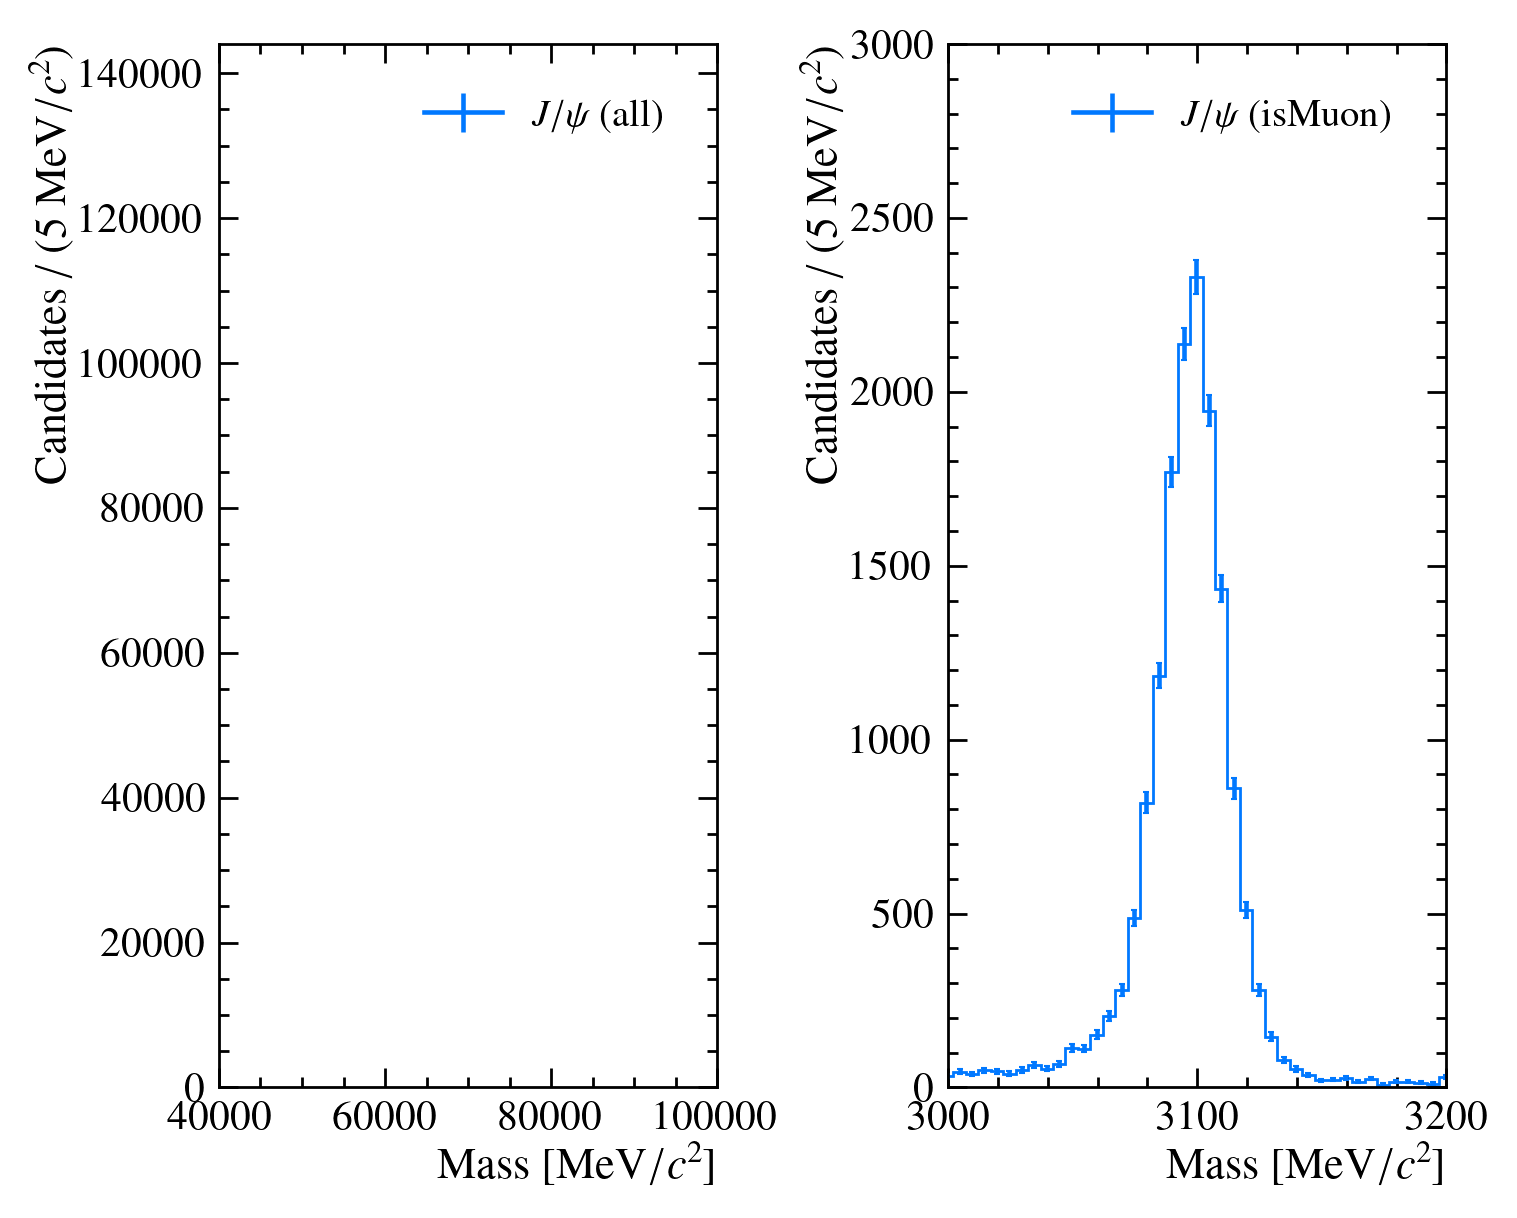

In [ ]:
fig_jpsi, (ax1_jpsi, ax2_jpsi) = plt.subplots(1, 2, figsize=(5*3, 4*3))

histogram_ax(
    [HistogramPlot(all_df["J_psi_1S_M"], r"$J/\psi$ (all)", True, 5)],
    ax1_jpsi,
    xlabel=r"Mass",
    xlim=[3000, 3200],
    ylim=[40e3,100e3],
    unit_tex=r"\mathrm{MeV}/c^2"
)

histogram_ax(
    [HistogramPlot(df["J_psi_1S_M"], r"$J/\psi$ (isMuon)", True, 5)],
    ax2_jpsi,
    xlabel=r"Mass",
    xlim=[3000, 3200],
    ylim=[0,3000],
    unit_tex=r"\mathrm{MeV}/c^2"
)

In [6]:
# all_df.to_csv("data/jpsi_data_5ltracks.csv")